 Loading dataset from: D:/Desktop/SML in Bioinformatics/Datasets/miniTCGA_dataset.csv

✅ Model Accuracies:
  Logistic Regression: 0.9862
  Random Forest:       0.9839


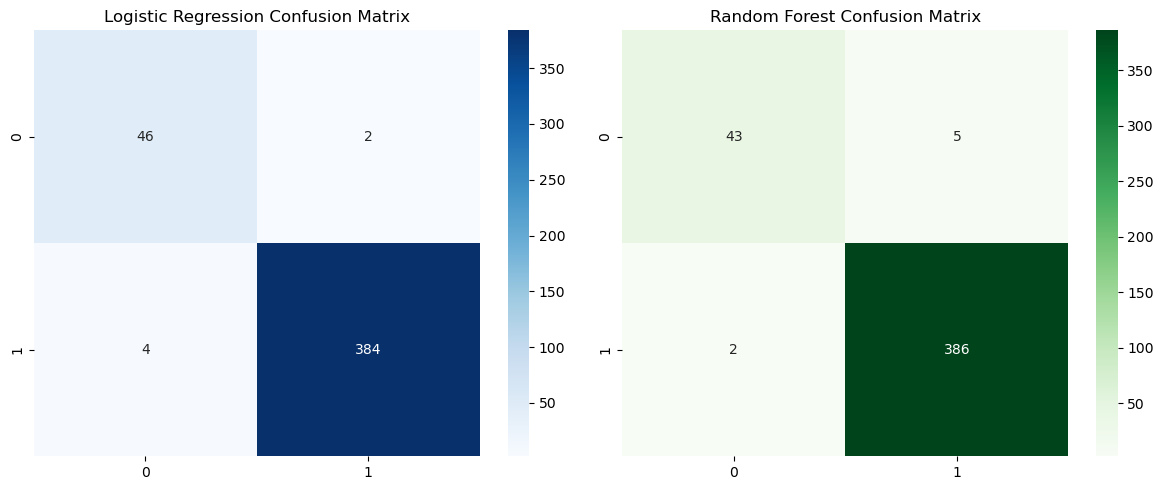

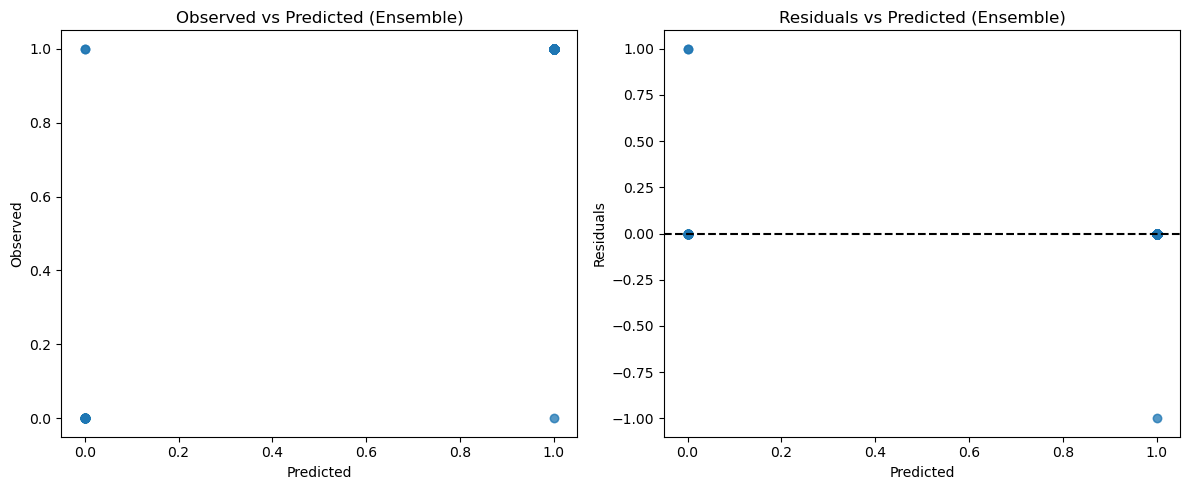


 Ensemble Accuracy: 0.9862

 Final predictions saved as tcga_final_predictions_round_2.csv. Use this in R to create .rds file for submission.


In [11]:
# TCGA Cancer Classification - Prediction Round 2


import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

# Load Dataset 
file_path = "D:/Desktop/SML in Bioinformatics/Datasets/miniTCGA_dataset.csv"  
print(f" Loading dataset from: {file_path}")

df = pd.read_csv(file_path)

# Prepare Data
train_df = df[df['response'].notna()]
test_df = df[df['response'].isna()]

X = train_df.drop(columns=['rowid', 'response', 'tissue'])
y = train_df['response']
X_test = test_df.drop(columns=['rowid', 'response', 'tissue'])


# Encode labels if needed
y = y.astype(str)

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

#  Train Models
# Logistic Regression
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)
y_pred_log = logreg.predict(X_val)
acc_log = accuracy_score(y_val, y_pred_log)

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_val)
acc_rf = accuracy_score(y_val, y_pred_rf)

# Evaluation
print("\n✅ Model Accuracies:")
print(f"  Logistic Regression: {acc_log:.4f}")
print(f"  Random Forest:       {acc_rf:.4f}")

# Confusion Matrix
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.heatmap(confusion_matrix(y_val, y_pred_log), annot=True, fmt='d', cmap='Blues')
plt.title("Logistic Regression Confusion Matrix")

plt.subplot(1, 2, 2)
sns.heatmap(confusion_matrix(y_val, y_pred_rf), annot=True, fmt='d', cmap='Greens')
plt.title("Random Forest Confusion Matrix")
plt.tight_layout()
plt.show()

#  Scatterplot Visualization
y_val_encoded = LabelEncoder().fit_transform(y_val)
y_pred_ensemble = pd.DataFrame({
    'logreg': y_pred_log,
    'rf': y_pred_rf
}).mode(axis=1)[0]
y_pred_encoded = LabelEncoder().fit(y_val).transform(y_pred_ensemble)

residuals = y_val_encoded - y_pred_encoded

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_pred_encoded, y_val_encoded, alpha=0.5)
plt.xlabel("Predicted")
plt.ylabel("Observed")
plt.title("Observed vs Predicted (Ensemble)")

plt.subplot(1, 2, 2)
plt.scatter(y_pred_encoded, residuals, alpha=0.5)
plt.axhline(0, color='black', linestyle='--')
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted (Ensemble)")
plt.tight_layout()
plt.show()

# Ensemble (Majority Voting)
val_preds_combined = pd.DataFrame({
    'logreg': y_pred_log,
    'rf': y_pred_rf
})

# Voting (row-wise majority)
ensemble_preds = val_preds_combined.mode(axis=1)[0]
ensemble_acc = accuracy_score(y_val, ensemble_preds)

print(f"\n Ensemble Accuracy: {ensemble_acc:.4f}")

# Final Predictions for Test Set
test_pred_log = logreg.predict(X_test)
test_pred_rf = rf.predict(X_test)
test_preds_combined = pd.DataFrame({
    'logreg': test_pred_log,
    'rf': test_pred_rf
})

final_preds = test_preds_combined.mode(axis=1)[0]

# Save Final Predictions as CSV 
submission = pd.DataFrame({
    'predicted': final_preds
})
submission.to_csv("tcga_final_predictions_round_2.csv", index=False)
print("\n Final predictions saved as tcga_final_predictions_round_2.csv.")


In [13]:
import os
os.getcwd()


'D:\\'